# [기초-실습] 통계 101x데이터 분석: (5-6장) 가설검정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [1]:
# [macOS 로컬 환경용] 필요한 라이브러리 설치
# 코랩 전용 코드(apt-get, sudo 등)는 제거했습니다. 한글 폰트는 macOS 기본 AppleGothic을 사용합니다.
!pip install -q statsmodels

In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'  # macOS 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 게임 아이템 뽑기 확률, 정말 10%일까? (난이도: 하)

**📘 문제**

- 어떤 게임 개발사에서 새로운 아이템의 뽑기 확률이 **10%**로 설정되었다고 주장하고 있습니다.

- 그런데 유저 커뮤니티에서는 "실제 확률은 10%보다 낮은 것 같다"는 의혹이 제기되었습니다.

- 이를 확인하기 위해 한 유저가 아이템을 **200번 뽑았고, 그중 12번 성공**했습니다.

- 이번 실습에서는 **이항검정(Binomial Test)**으로 이 결과가 개발사의 주장을 기각할 만큼 유의미한지 확인하고,
  시뮬레이션을 통해 **p-값이 무엇을 의미하는지**를 직접 눈으로 확인해 봅니다.

In [3]:
# 문제 설정
n = 200  # 총 시행 횟수
x = 12   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)


### [문제 1] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
- H₀ (귀무가설): 실제 확률이 10%이다.
- H₁ (대립가설): 실제 확률이 10%보다 낮다.


In [4]:
# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?

# 여기에 코드를 작성해주세요.
result = stats.binomtest(x, n, p, alternative='less')
p_value = result.pvalue
print(f"p-value: {p_value:.4f}")


p-value: 0.0320


In [6]:
# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

# 여기에 코드를 작성해주세요.
alpha = 0.05
if p_value < alpha:
    print(f"p-value({p_value:.4f}) < alpha({alpha}) → 귀무가설 기각")
    print("→ 실제 확률은 10%보다 낮다고 볼 수 있는 유의미한 증거가 있다.")
else:
    print(f"p-value({p_value:.4f}) >= alpha({alpha}) → 귀무가설 기각 실패")



p-value(0.0320) < alpha(0.05) → 귀무가설 기각
→ 실제 확률은 10%보다 낮다고 볼 수 있는 유의미한 증거가 있다.


In [8]:
# [문제 1] Q4. H₀가 사실(실제 확률 = 10%)이라고 가정하고,
# 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.
# 힌트: numpy의 이항분포 랜덤 함수(np.random.binomial)를 사용해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(42)
n_simulations = 10000
simulated_successes = np.random.binomial(n=n, p=p, size=n_simulations)


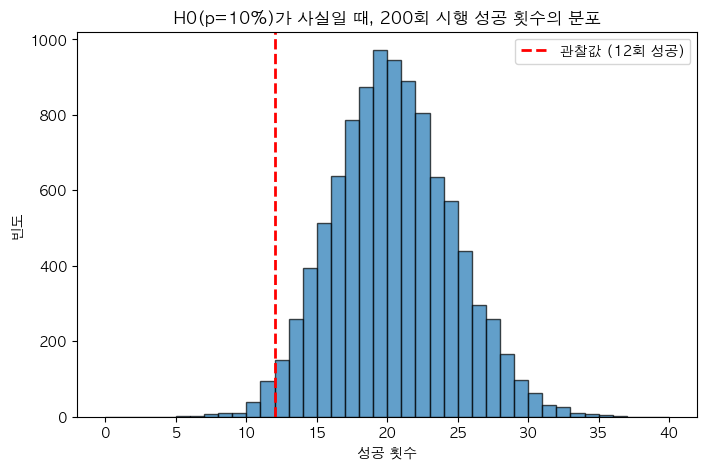

In [10]:
# [문제 1] Q5. 시뮬레이션 결과를 히스토그램으로 그려봅시다.
# 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
plt.figure(figsize=(8, 5))
plt.hist(simulated_successes, bins=range(0, 41), edgecolor='black', alpha=0.7)
plt.axvline(x=x, color='red', linestyle='--', linewidth=2, label=f'관찰값 ({x}회 성공)')
plt.title("H0(p=10%)가 사실일 때, 200회 시행 성공 횟수의 분포")
plt.xlabel("성공 횟수"); plt.ylabel("빈도"); plt.legend(); plt.show()


**🧠 데이터를 어떻게 읽을까요?**

- Q2에서 구한 p-값은 시뮬레이션 그래프의 어느 부분에 해당하며, 무엇을 의미하나요?

- 시뮬레이션 그래프를 볼 때, 우리가 관찰한 '12회 성공'은 개발사의 주장이 맞다는 가정 하에 흔한 일인가요, 드문 일인가요?

- 이 시뮬레이션 경험을 통해 "p-값이 작으면 귀무가설을 기각한다"는 규칙을 친구에게 어떻게 더 쉽게 설명할 수 있을까요?

- 만약 200번이 아니라 1,000번을 뽑아 같은 성공률(6%)이 나왔다면, p-값은 어떻게 달라질까요?

### [문제 1] 데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- Q2에서 구한 p-값은 그래프의 양 끝쪽에 해당하며 유의수준을 의미한다.
- 드문일이다.
- 이 시뮬레이션에서 귀무가설이 참이라는 가정하에 10000번의 시뮬레이션을 돌렸는데 직접 관찰한 12번 이하의 성공 횟수는 320개이다. 즉 p-값이 0.032인것인데 귀무가설이 맞다면 10000번중에 320번만 일어나야하는데 실제로 내가 관측한 결과에서 일어났으니 귀무가설이 틀렸다고 주장할 수 있다.
- 1000번을 뽑아도 성공률이 6%라면 표본크기가 커지면 표본오차가 줄어들기때문에 극단성이 커진다. 그렇기에 더 작아진다.

# 문제 2. 과자 한 봉지의 중량은 150g이 맞을까? (난이도: 하)

**📘 문제**

- 한 식품 공장에서 생산하는 과자 한 봉지의 **목표 중량은 150g**입니다.

- 품질관리팀은 생산 공정이 목표 중량을 잘 맞추고 있는지 확인하기 위해,
  생산된 과자 **30봉지를 무작위로 추출**하여 무게를 측정했습니다.

- 이번 실습에서는 **일표본 t-검정(One-sample t-Test)**으로 표본 평균이 목표 중량과 유의미하게 다른지 검증하고,
  **"평균이 정확히 150g이라면"** 어떤 표본 평균들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

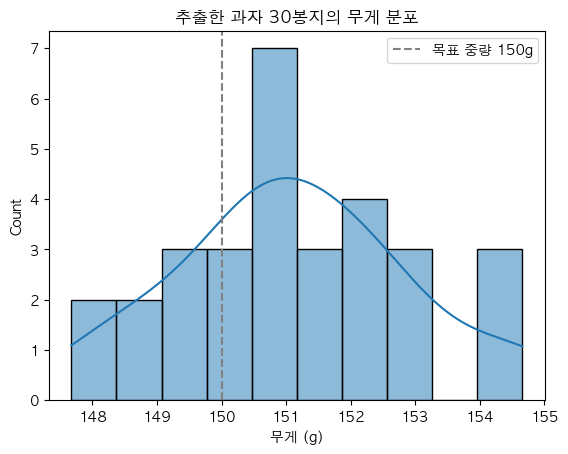

In [12]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 일표본 t-검정을 수행하여 t-통계량과 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"평균 무게가 정확히 150g이라면"** 30개짜리 표본의 평균이 어떻게 분포하는지 10,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 표본 평균이 그 분포에서 어디에 위치하는지 관찰해 봅시다.

In [ ]:
# [문제 2] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 평균 중량이 150g이다.
# H₁ (대립가설): 평균 중량이 150g이 아니다.

In [13]:
# [문제 2] Q2. 일표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.

# 여기에 코드를 작성해주세요.
t_stat, p_value = stats.ttest_1samp(sample_weights, pop_mean)
print(f"t-통계량: {t_stat:.4f}, p-value: {p_value:.4f}")


t-통계량: 3.4193, p-value: 0.0019


In [14]:
# [문제 2] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

# 여기에 코드를 작성해주세요.
alpha = 0.05
if p_value < alpha:
    print("귀무가설 기각 → 평균 중량은 150g과 유의미하게 다르다.")
else:
    print("귀무가설 기각 실패")


귀무가설 기각 → 평균 중량은 150g과 유의미하게 다르다.


In [15]:
# [문제 2] Q4. H₀가 사실(평균 = 150g)이라고 가정하고, 30개짜리 표본을 10,000번 뽑아
# 각 표본의 평균을 리스트에 저장해봅시다.
# 힌트: 표준편차는 우리가 가진 표본의 표준편차를 사용한다고 가정하고, for 반복문을 사용해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(42)
sample_std = sample_weights.std(ddof=1)
sample_size = len(sample_weights)
simulated_means = []
for _ in range(10000):
    sim_sample = np.random.normal(loc=pop_mean, scale=sample_std, size=sample_size)
    simulated_means.append(sim_sample.mean())
simulated_means = np.array(simulated_means)


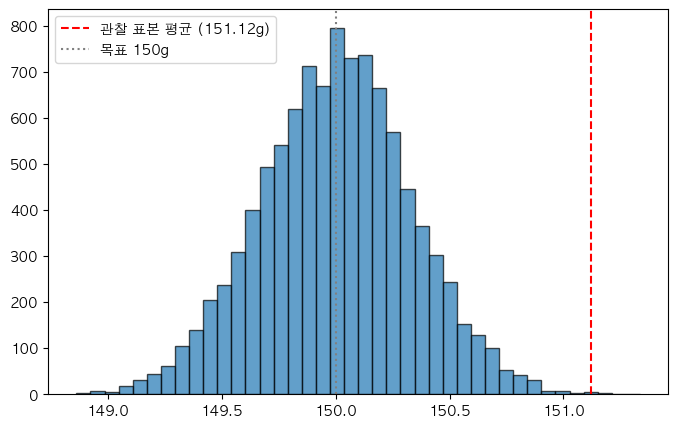

In [16]:
# [문제 2] Q5. 시뮬레이션으로 얻은 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 표본 평균을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
observed_mean = sample_weights.mean()
plt.figure(figsize=(8, 5))
plt.hist(simulated_means, bins=40, edgecolor='black', alpha=0.7)
plt.axvline(x=observed_mean, color='red', linestyle='--', label=f'관찰 표본 평균 ({observed_mean:.2f}g)')
plt.axvline(x=pop_mean, color='gray', linestyle=':', label='목표 150g')
plt.legend(); plt.show()


**🧠 데이터를 어떻게 읽을까요?**

- Q5의 히스토그램은 무엇을 나타내나요? 이 분포의 모양이 정규분포와 비슷한 이유는 무엇일까요? (힌트: 4장에서 배운 중심극한정리)

- 우리가 실제로 관찰한 표본 평균(세로선)은 이 분포에서 흔하게 나타나는 값인가요? Q2의 p-값과 이 시각적 위치는 어떻게 관련되나요?

- 만약 p-값이 0.001이었다면, 세로선은 그래프의 어디쯤에 위치할 것으로 예상되나요?

- 이 결과는 공장 입장에서 어떤 조치를 취해야 함을 시사할까요? (목표보다 무겁게 나오는 것은 어떤 손실일까요?)

### [문제 2] 데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- 평균이 150g일때 30개짜리 표본을 뽑으면 표본평균이 어떻게 나오는지를 보여준다. 중심극한정리에 의해 표본크기가 충분하면 원래 데이터 분포와 무관하게 표본평균의 분포는 정규분포에 가까워지기 때문에 정규분포와 비슷하다.
- 흔하게 나타나지 않는 값이다. p-값이 작을수록 시각적 위치는 중심에서 멀어진다.
- p-값이 0.001이었다면 지금보다 조금 더 중심에서 멀어진 위치였을것이다.
- 공장입장에서는 관찰표본평균이 151.12g이기때문에 재료비 손실이 있어 150g을 맞추기 위해 재조정해야한다.

# 문제 3. 어떤 온라인 학습 방식이 더 효과적일까? (난이도: 중)

**📘 문제**

- 한 교육 기업에서 두 가지 다른 온라인 학습 방식(A, B)을 개발했습니다.

- 방식 A가 방식 B보다 학생들의 성적 향상에 더 효과적인지 알아보기 위해,
  두 그룹의 학생들에게 각각 다른 방식으로 한 달간 학습시킨 후 시험을 보게 했습니다.

- 이번 실습에서는 **이표본 t-검정(Two-sample t-Test)**으로 두 방식의 평균 점수 차이를 검증합니다.
  단, t-검정의 기본 가정인 **정규성**과 **등분산성**을 먼저 확인해야 합니다.

- 또한 **"두 방식의 효과가 완전히 똑같다면"** 우연히 나타날 수 있는 점수 차이의 범위를 시뮬레이션으로 확인해 봅니다.

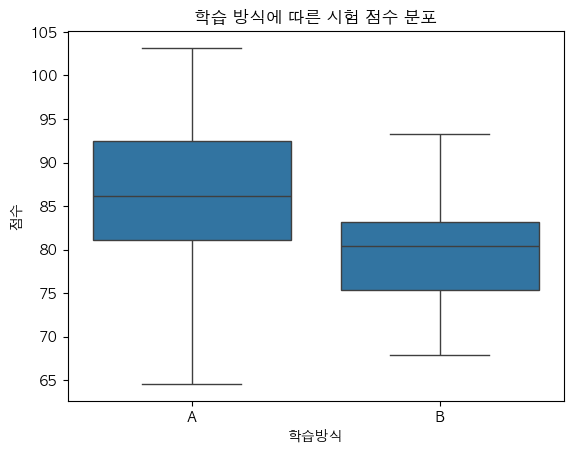

In [ ]:
# 데이터 생성 (두 학습 방식의 시험 점수)
np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)

df_scores = pd.DataFrame({'점수': np.concatenate([group_a_scores, group_b_scores]),
                        '학습방식': ['A']*50 + ['B']*50})

# 두 그룹의 점수 분포 시각화
sns.boxplot(x='학습방식', y='점수', data=df_scores)
plt.title("학습 방식에 따른 시험 점수 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 두 그룹에 대해 **정규성 검정(Shapiro-Wilk test)**을 수행해 봅시다. (H₀: 데이터는 정규분포를 따른다.)

- **등분산성 검정(Levene's test)**을 수행해 봅시다. (H₀: 두 그룹의 분산은 같다.)

- 가정 검토 결과에 따라 `equal_var` 인수를 설정하여 **이표본 t-검정**을 수행해 봅시다.

- 두 그룹 데이터를 모두 합친 뒤 무작위로 다시 나누는 방식으로, **"두 방식의 효과가 같을 때"**의 평균 차이 분포를 시뮬레이션해 봅시다.

In [32]:
# [문제 3] Q1. 두 그룹에 대해 각각 정규성 검정(Shapiro-Wilk test)을 수행하고 p-값을 출력해봅시다.
# H₀: 데이터는 정규분포를 따른다.

# 여기에 코드를 작성해주세요.
stat_a, p_a = stats.shapiro(group_a_scores)
stat_b, p_b = stats.shapiro(group_b_scores)
print("정규성 검정을 수행한 A그룹의 p-값 :",p_a)
print("정규성 검정을 수행한 B그룹의 p-값 :", p_b)

정규성 검정을 수행한 A그룹의 p-값 : 0.87655329658421
정규성 검정을 수행한 B그룹의 p-값 : 0.8365820927111655


In [29]:
# [문제 3] Q2. 두 그룹에 대해 등분산성 검정(Levene's test)을 수행하고 p-값을 출력해봅시다.
# H₀: 두 그룹의 분산은 같다.

# 여기에 코드를 작성해주세요.
levene_stat, levene_p = stats.levene(group_a_scores, group_b_scores)
print("등분산 검정 후 p-값 :",levene_p)


등분산 검정 후 p-값 : 0.01498158908561773


In [33]:
# [문제 3] Q3. 이표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.
# H₀: 두 그룹의 평균은 같다. / H₁: 두 그룹의 평균은 다르다.
# 등분산성 가정을 만족했는지 여부에 따라 equal_var 인수를 설정해보세요.

# 여기에 코드를 작성해주세요.
equal_var = levene_p >= 0.05
t_stat, p_value = stats.ttest_ind(group_a_scores, group_b_scores, equal_var=equal_var)
print("이표본 t-검정 수행 후 t-통계량 :",t_stat)
print("이표본 t-검정 수행 후 p-값", p_value)

이표본 t-검정 수행 후 t-통계량 : 4.0425693188528316
이표본 t-검정 수행 후 p-값 0.00011486850389345317


In [22]:
# [문제 3] Q4. H₀가 사실(두 그룹의 평균이 같다)이라고 가정하고 시뮬레이션을 10,000번 수행해봅시다.
# 두 그룹의 데이터를 모두 합친 뒤(np.concatenate), 매 반복마다 비복원추출로 50개(가상 A그룹)와
# 나머지 50개(가상 B그룹)로 나누어 두 그룹의 평균 차이를 계산하고 리스트에 저장해보세요.
# 힌트: np.random.permutation 을 사용해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(0)
all_scores = np.concatenate([group_a_scores, group_b_scores])
n_a = len(group_a_scores)
simulated_diffs = []
for _ in range(10000):
    shuffled = np.random.permutation(all_scores)
    simulated_diffs.append(shuffled[:n_a].mean() - shuffled[n_a:].mean())
simulated_diffs = np.array(simulated_diffs)



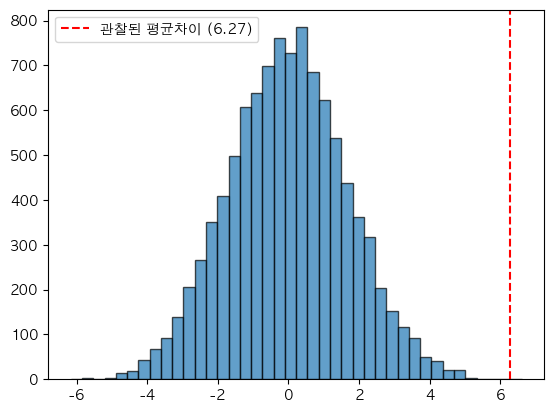

In [31]:
# [문제 3] Q5. 시뮬레이션으로 얻은 평균 차이의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 평균 차이(A그룹 평균 - B그룹 평균)를 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
observed_diff = group_a_scores.mean() - group_b_scores.mean()
plt.hist(simulated_diffs, bins=40, edgecolor='black', alpha=0.7)
plt.axvline(x=observed_diff, color='red', linestyle='--', label=f'관찰된 평균차이 ({observed_diff:.2f})')
plt.legend(); plt.show()


**🧠 데이터를 어떻게 읽을까요?**

- 정규성 검정과 등분산성 검정의 p-값은 각각 어떻게 해석해야 하나요? 이 결과는 이표본 t-검정을 사용하는 데 문제가 없음을 보여주나요?

- Q5의 히스토그램 중심이 0에 가까운 이유는 무엇일까요?

- 실제 관찰된 평균 차이(세로선)는 "두 방식의 효과가 같다"고 가정했을 때 우연히 나타날 수 있는 범위 안에 있나요, 벗어나나요?

- 이 시각적 판단과 Q3의 p-값은 어떤 관계가 있나요?

- 통계적으로 유의미한 차이가 있다면, 교육 기업은 이 결과를 어떻게 활용할 수 있을까요?

In [ ]:
### [문제 3] 데이터를 어떻게 읽을까요?
#### 여기에 의견을 작성해주세요.

- 

# 문제 4. 연령대별로 선호하는 영화 장르가 다를까? (난이도: 중)

**📘 문제**

- 한 영화관에서 고객의 **연령대(20대, 30대, 40대)**에 따라 선호하는 **영화 장르(액션, 로맨스)**에 차이가 있는지 궁금해졌습니다.

- 이를 알아보기 위해 300명의 고객을 대상으로 설문조사를 진행하여 분할표를 얻었습니다.

- 이번 실습에서는 **카이제곱 독립성 검정(Chi-squared Test of Independence)**으로
  두 범주형 변수 사이에 연관성이 있는지 검증합니다.

- 또한 **"두 변수가 서로 아무 관련이 없다면(독립이라면)"** 어떤 카이제곱 통계량들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

In [ ]:
# 데이터 생성 (관측 빈도 분할표)
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])

print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 카이제곱 독립성 검정을 수행하여 카이제곱 통계량, p-값, 자유도, **기대 빈도**를 구해봅시다.

- **"연령대와 선호 장르가 독립이라면"** 어떤 분할표들이 나타날 수 있는지 5,000번 시뮬레이션해 봅시다.

- 시뮬레이션으로 얻은 카이제곱 통계량 분포와 실제 관찰된 카이제곱 통계량을 비교해 봅시다.

In [ ]:
# [문제 4] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설):
# H₁ (대립가설):

In [ ]:
# [문제 4] Q2. 카이제곱 독립성 검정을 수행하고 카이제곱 통계량, p-값, 자유도, 기대 빈도를 구해봅시다.
# 기대 빈도는 관측 빈도와 비교하기 쉽도록 데이터프레임 형태로 출력해보세요.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 4] Q3. H₀가 사실(두 변수가 독립)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 각 반복마다 300명의 가상 고객에게 연령대와 장르를 '독립적으로' 할당한 후,
# 가상 분할표를 만들고 카이제곱 통계량을 계산하여 리스트에 저장해보세요.
# 힌트 1: 전체 비율(observed.sum(axis=0) / 전체, observed.sum(axis=1) / 전체)을 확률로 사용
# 힌트 2: np.random.choice 로 300명의 연령대와 장르를 각각 독립적으로 생성
# 힌트 3: pd.crosstab 으로 분할표 생성 후 stats.chi2_contingency 로 통계량 계산

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 4] Q4. 시뮬레이션으로 얻은 카이제곱 통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 카이제곱 통계량을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- '기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요?

- Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요?

- 유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요?

- 이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?

In [ ]:
# [문제 4] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# 문제 5. 미니 프로젝트 - 어떤 신규 비료가 가장 효과적일까? (난이도: 상)

**📘 문제**

- 한 농업 연구소에서 새로 개발한 비료 3종류(A, B, C)의 생산량 증대 효과를 비교하고자 합니다.

- 동일한 조건의 밭 30개를 준비하여, 각각 10개씩 비료 A, B, C를 투여한 후 수확량을 측정했습니다.

- 이번 실습에서는 **분산분석(ANOVA)**으로 세 비료 간 평균 수확량에 차이가 있는지 검증하고,
  차이가 있다면 **사후분석(Tukey's HSD)**으로 어떤 비료끼리 차이가 나는지 확인합니다.

- 마지막으로 **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량이 나올 수 있는지 시뮬레이션하고,
  분석 결과를 바탕으로 연구소에 어떤 비료를 추천할지까지 생각해 봅니다.

In [ ]:
# 데이터 생성 (비료 종류별 수확량)
np.random.seed(123)
fertilizer_a = np.random.normal(loc=105, scale=10, size=10)
fertilizer_b = np.random.normal(loc=120, scale=12, size=10)
fertilizer_c = np.random.normal(loc=108, scale=9, size=10)

# 데이터프레임으로 변환 (사후분석을 위해)
df = pd.DataFrame({'수확량': np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c]),
                   '비료종류': ['A']*10 + ['B']*10 + ['C']*10})

# 데이터 탐색 시각화
sns.boxplot(x='비료종류', y='수확량', data=df)
plt.title("비료 종류에 따른 수확량 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 세 그룹에 대해 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.

- ANOVA 결과가 유의미할 경우에만 **Tukey's HSD 사후분석**을 수행하고 결과를 해석해 봅시다.

- **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량들이 나오는지 5,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 F-통계량이 얼마나 극단적인 값인지 확인해 봅시다.

- 분석 결과를 종합하여 연구소에 추천할 비료를 정해 봅시다.

In [ ]:
# [문제 5] Q1. 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.
# H₀: 세 비료의 평균 수확량은 모두 같다.
# H₁: 적어도 하나 이상의 비료 평균 수확량은 다르다.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q2. ANOVA의 p-값이 유의수준 0.05보다 작을 경우에만
# Tukey's HSD 사후분석을 수행하고 결과를 출력해봅시다.
# 힌트: pairwise_tukeyhsd(endog=수확량, groups=비료종류, alpha=0.05)

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q3. H₀가 사실(세 그룹의 평균이 모두 같다)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 모든 데이터를 합친 평균과 표준편차를 가진 H₀ 모집단에서 10개씩 3개의 가상 그룹을 생성하고,
# 이 가상 그룹들로 ANOVA를 수행하여 F-통계량을 리스트에 저장해보세요.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q4. 시뮬레이션으로 얻은 F-통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 F-통계량을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q5. 분석 결과를 바탕으로 연구소에 어떤 비료를 추천하시겠습니까?
# 여기에 의견을 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- ANOVA 검정의 p-값을 통해 어떤 결론을 내릴 수 있나요? 이 결과는 "세 비료가 모두 동일한 효과를 가진다"는 뜻인가요, "적어도 하나는 다르다"는 뜻인가요?

- Tukey's HSD 결과표의 `reject` 열에서 `True`로 표시된 조합은 무엇이며, 이는 무엇을 의미하나요?

- `meandiff` 열의 값은 어떤 정보를 주나요? 신뢰구간(`lower`, `upper`)이 0을 포함하는지 여부는 무엇을 뜻할까요?

- 그룹별 표본 크기가 10개로 작다는 점은 이 결론의 신뢰도에 어떤 영향을 줄까요? 어떻게 개선할 수 있을까요?

In [ ]:
# [문제 5] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.